# LU-felbontás és Normák

Ez a notebook a **numerikus módszerek** kurzus 3. és 4. előadásának anyagát szemlélteti interaktív Python példákkal.

**Tartalom:**

**I. rész – LU-felbontás**
1. Alsó háromszögmátrixok és Gauss-elimináció
2. Háromszögmátrixok tulajdonságai
3. Az $L_k$ mátrixok tulajdonságai
4. LU-felbontás Gauss-eliminációval
5. LU-felbontás közvetlen kiszámítása
6. LER megoldása LU-felbontással
7. Műveletigény: GE vs LU

**II. rész – Vektor- és mátrixnormák**
8. Vektornormák
9. Egységgömbök vizualizációja
10. Mátrixnormák
11. Indukált mátrixnorma szemléltetése
12. Spektrálsugár

**III. rész – Feladatok**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.set_printoptions(precision=4, suppress=True)

---
# I. rész – LU-felbontás

## 1. Alsó háromszögmátrixok és Gauss-elimináció

Az előző előadáson láttuk, hogy a Gauss-elimináció (GE) $k$-adik lépésében a $k$-adik oszlop alatti elemeket nullázzuk ki. Ezt a lépést **mátrixszorzásként** is felírhatjuk!

### Balról szorzás alsó háromszögmátrixszal

Ha az $L$ alsó háromszögmátrixszal balról szorzunk egy $A$ mátrixot, az $A$ **sorait kombináljuk**.

Például:
$$
\begin{bmatrix} 1 & 0 & 0 \\ 2 & 1 & 0 \\ -3 & 0 & 1 \end{bmatrix}
\cdot A
$$
az 1. sor kétszeresét hozzáadja a 2. sorhoz, és az 1. sor háromszorosát levonja a 3. sorból. Ez pont a GE 1. lépése!

In [2]:
# Példa az előadásból
A = np.array([[2, 0, 3],
              [-4, 5, -2],
              [6, -5, 4]], dtype=float)

print("A mátrix:")
print(A)

A mátrix:
[[ 2.  0.  3.]
 [-4.  5. -2.]
 [ 6. -5.  4.]]


In [3]:
# GE 1. lépése mátrixszorzásként
# Az L1 mátrixot úgy képezzük, hogy az I mátrix 1. oszlopába
# beírjuk a GE-s hányadosokat (ellentétes előjellel a főátló alatt)

# Szorzók: m21 = -4/2 = -2, m31 = 6/2 = 3
L1 = np.array([[1,  0, 0],
               [2,  1, 0],   # -m21 = -(-2) = 2
               [-3, 0, 1]], dtype=float)  # -m31 = -(3) = -3

A1 = L1 @ A
print("L1 =")
print(L1)
print("\nA^(1) = L1 · A =")
print(A1)

L1 =
[[ 1.  0.  0.]
 [ 2.  1.  0.]
 [-3.  0.  1.]]

A^(1) = L1 · A =
[[ 2.  0.  3.]
 [ 0.  5.  4.]
 [ 0. -5. -5.]]


In [4]:
# GE 2. lépése mátrixszorzásként
# Szorzó: m32 = -5/5 = -1
L2 = np.array([[1, 0, 0],
               [0, 1, 0],
               [0, 1, 1]], dtype=float)  # -m32 = -(-1) = 1

U = L2 @ A1
print("L2 =")
print(L2)
print("\nA^(2) = L2 · A^(1) = U =")
print(U)
print("\nTehát: L2 · L1 · A = U (felső háromszög alak)")

L2 =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 1.]]

A^(2) = L2 · A^(1) = U =
[[ 2.  0.  3.]
 [ 0.  5.  4.]
 [ 0.  0. -1.]]

Tehát: L2 · L1 · A = U (felső háromszög alak)


### Az LU-felbontás ötlete

Ha $L_2 \cdot L_1 \cdot A = U$, akkor fejezzük ki $A$-t:

$$
A = L_1^{-1} \cdot L_2^{-1} \cdot U =: L \cdot U
$$

ahol $L := L_1^{-1} \cdot L_2^{-1}$ alsó háromszögmátrix.

In [5]:
# L_k inverze: az átló alatti elemek előjelet váltanak
L1_inv = np.array([[1,  0, 0],
                   [-2, 1, 0],
                   [3,  0, 1]], dtype=float)

L2_inv = np.array([[1, 0, 0],
                   [0, 1, 0],
                   [0, -1, 1]], dtype=float)

print("L1^{-1} =")
print(L1_inv)
print(f"\nEllenőrzés: L1 @ L1_inv = I? {np.allclose(L1 @ L1_inv, np.eye(3))}")

print("\nL2^{-1} =")
print(L2_inv)
print(f"Ellenőrzés: L2 @ L2_inv = I? {np.allclose(L2 @ L2_inv, np.eye(3))}")

L1^{-1} =
[[ 1.  0.  0.]
 [-2.  1.  0.]
 [ 3.  0.  1.]]

Ellenőrzés: L1 @ L1_inv = I? True

L2^{-1} =
[[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 0. -1.  1.]]
Ellenőrzés: L2 @ L2_inv = I? True


In [6]:
# L = L1^{-1} · L2^{-1}: "szépen" szorzódnak!
L = L1_inv @ L2_inv
print("L = L1^{-1} · L2^{-1} =")
print(L)
print("\nU =")
print(U)
print(f"\nEllenőrzés: L @ U = A? {np.allclose(L @ U, A)}")

L = L1^{-1} · L2^{-1} =
[[ 1.  0.  0.]
 [-2.  1.  0.]
 [ 3. -1.  1.]]

U =
[[ 2.  0.  3.]
 [ 0.  5.  4.]
 [ 0.  0. -1.]]

Ellenőrzés: L @ U = A? True


## 2. Háromszögmátrixok tulajdonságai

**Definíció:** Egy $L \in \mathbb{R}^{n \times n}$ mátrixot **alsó háromszögmátrixnak** nevezzük, ha $l_{ij} = 0$ minden $i < j$ esetén (a főátló felett csupa nulla).

**Definíció:** Egy $U \in \mathbb{R}^{n \times n}$ mátrixot **felső háromszögmátrixnak** nevezzük, ha $u_{ij} = 0$ minden $i > j$ esetén (a főátló alatt csupa nulla).

**Jelölések:**
- $\mathcal{L}$: alsó háromszögmátrixok halmaza
- $\mathcal{L}_1$: egységátlójú alsó háromszögmátrixok ($l_{ii} = 1$)
- $\mathcal{U}$: felső háromszögmátrixok halmaza
- $\mathcal{U}_1$: egységátlójú felső háromszögmátrixok ($u_{ii} = 1$)

### Zártsági tulajdonságok

| Állítás | |
|---------|---|
| Ha $L', L'' \in \mathcal{L}$, akkor $L' \cdot L'' \in \mathcal{L}$ | Szorzat zárt |
| Ha $L \in \mathcal{L}_1$, akkor $\exists L^{-1} \in \mathcal{L}_1$ | Inverz zárt |

In [7]:
# Demonstráció: alsó háromszögmátrixok szorzata is alsó háromszög
L_a = np.array([[2, 0, 0],
                [3, 1, 0],
                [4, 5, 6]], dtype=float)

L_b = np.array([[1, 0, 0],
                [7, 2, 0],
                [8, 9, 3]], dtype=float)

L_prod = L_a @ L_b
print("L_a · L_b =")
print(L_prod)
print("\n→ Alsó háromszög? Igen! (a főátló felett csupa nulla)")

# Egységátlójú alsó háromszögmátrixok
L_c = np.array([[1, 0, 0],
                [3, 1, 0],
                [2, 5, 1]], dtype=float)

L_c_inv = np.linalg.inv(L_c)
print("\nL_c =")
print(L_c)
print("\nL_c^{-1} =")
print(L_c_inv)
print("→ Az inverz is egységátlójú alsó háromszög!")

L_a · L_b =
[[ 2.  0.  0.]
 [10.  2.  0.]
 [87. 64. 18.]]

→ Alsó háromszög? Igen! (a főátló felett csupa nulla)

L_c =
[[1. 0. 0.]
 [3. 1. 0.]
 [2. 5. 1.]]

L_c^{-1} =
[[ 1.  0.  0.]
 [-3.  1.  0.]
 [13. -5.  1.]]
→ Az inverz is egységátlójú alsó háromszög!


## 3. Az $L_k$ mátrixok tulajdonságai

### Definíció

$$
L_k := I - \ell_k \mathbf{e}_k^\top, \quad \text{ahol } \ell_k = \begin{pmatrix} 0 \\ \vdots \\ 0 \\ l_{k+1,k} \\ \vdots \\ l_{nk} \end{pmatrix}
$$

és $l_{ik} = \frac{a_{ik}^{(k-1)}}{a_{kk}^{(k-1)}}$ a GE-s hányadosok.

### $L_k$ inverze

$$
L_k^{-1} = I + \ell_k \mathbf{e}_k^\top
$$

Azaz az inverz mátrixot úgy kapjuk, hogy az átló alatti elemek előjelet váltanak.

### $L_k^{-1}$ mátrixok szorzata

$$
L_1^{-1} \cdot L_2^{-1} \cdots L_{n-1}^{-1} = I + \ell_1 \mathbf{e}_1^\top + \ell_2 \mathbf{e}_2^\top + \ldots + \ell_{n-1} \mathbf{e}_{n-1}^\top
$$

Tehát $L$ mátrixot egyszerűen úgy kapjuk, hogy az $\ell_k$ vektorokat oszloponként beírjuk az egységmátrixba!

In [8]:
# Demonstráció: L_k^{-1} mátrixok "szépen" szorzódnak

# Két tetszőleges L_k^{-1} típusú mátrix
Linv1 = np.array([[1, 0, 0],
                  [2, 1, 0],
                  [1, 0, 1]], dtype=float)

Linv2 = np.array([[1, 0, 0],
                  [0, 1, 0],
                  [0, 3, 1]], dtype=float)

print("L1^{-1} =")
print(Linv1)
print("\nL2^{-1} =")
print(Linv2)
print("\nL1^{-1} · L2^{-1} =")
print(Linv1 @ Linv2)
print("\n→ Az elemek egyszerűen 'összefésülődnek': az 1. oszlopba")
print("  az L1^{-1} alatti elemei, a 2. oszlopba az L2^{-1} alatti elemei kerülnek.")

L1^{-1} =
[[1. 0. 0.]
 [2. 1. 0.]
 [1. 0. 1.]]

L2^{-1} =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 3. 1.]]

L1^{-1} · L2^{-1} =
[[1. 0. 0.]
 [2. 1. 0.]
 [1. 3. 1.]]

→ Az elemek egyszerűen 'összefésülődnek': az 1. oszlopba
  az L1^{-1} alatti elemei, a 2. oszlopba az L2^{-1} alatti elemei kerülnek.


## 4. LU-felbontás Gauss-eliminációval

### Definíció: LU-felbontás

Az $A$ mátrix **LU-felbontásának** nevezzük az $L \cdot U$ szorzatot, ha:

$$
A = L \cdot U, \quad L \in \mathcal{L}_1, \quad U \in \mathcal{U}
$$

ahol $L$ egységátlójú alsó háromszögmátrix és $U$ felső háromszögmátrix.

### Előállítás GE-vel

A Gauss-elimináció lépéseit felírhatjuk:
$$L_{n-1} \cdots L_2 \cdot L_1 \cdot A = U$$

Innen:
$$A = L_1^{-1} \cdot L_2^{-1} \cdots L_{n-1}^{-1} \cdot U = L \cdot U$$

Az $L$ mátrix elemeit egyszerűen a GE-s hányadosokból kapjuk!

### Tétel: LU-felbontás létezése és egyértelműsége

- Ha a GE végrehajtható sor és oszlopcsere nélkül (azaz $a_{kk}^{(k-1)} \neq 0$ minden $k$-ra), akkor az $A$ mátrix LU-felbontása **létezik**.
- Ha $\det(A) \neq 0$, akkor a felbontás **egyértelmű**.

In [9]:
def lu_decomposition_ge(A, verbose=False):
    """
    LU-felbontás Gauss-eliminációval.
    
    Visszatérési értékek:
        L: egységátlójú alsó háromszögmátrix
        U: felső háromszögmátrix
    """
    n = A.shape[0]
    U = A.astype(float).copy()
    L = np.eye(n)
    
    for k in range(n - 1):
        if U[k, k] == 0:
            raise ValueError(f"Nulla pivot a {k+1}. lépésben! LU-felbontás nem létezik (sorcsere nélkül).")
        for i in range(k + 1, n):
            m = U[i, k] / U[k, k]
            L[i, k] = m  # hányadost eltároljuk L-ben
            U[i, k:] -= m * U[k, k:]
        
        if verbose:
            print(f"--- {k+1}. lépés után ---")
            print(f"U =\n{U}")
            print(f"L (eddig) =\n{L}\n")
    
    return L, U

In [10]:
# Példa az előadásból
A = np.array([[2, 0, 3],
              [-4, 5, -2],
              [6, -5, 4]], dtype=float)

L, U = lu_decomposition_ge(A, verbose=True)

print("Végeredmény:")
print(f"L =\n{L}")
print(f"\nU =\n{U}")
print(f"\nL @ U =\n{L @ U}")
print(f"\nA =\n{A}")
print(f"\nL @ U = A? {np.allclose(L @ U, A)}")

--- 1. lépés után ---
U =
[[ 2.  0.  3.]
 [ 0.  5.  4.]
 [ 0. -5. -5.]]
L (eddig) =
[[ 1.  0.  0.]
 [-2.  1.  0.]
 [ 3.  0.  1.]]

--- 2. lépés után ---
U =
[[ 2.  0.  3.]
 [ 0.  5.  4.]
 [ 0.  0. -1.]]
L (eddig) =
[[ 1.  0.  0.]
 [-2.  1.  0.]
 [ 3. -1.  1.]]

Végeredmény:
L =
[[ 1.  0.  0.]
 [-2.  1.  0.]
 [ 3. -1.  1.]]

U =
[[ 2.  0.  3.]
 [ 0.  5.  4.]
 [ 0.  0. -1.]]

L @ U =
[[ 2.  0.  3.]
 [-4.  5. -2.]
 [ 6. -5.  4.]]

A =
[[ 2.  0.  3.]
 [-4.  5. -2.]
 [ 6. -5.  4.]]

L @ U = A? True


### Tömör írásmód

A GE-s hányadosokat nem kell külön tárolni: az eliminált pozíciókon (ahol éppen nullát hoztunk létre $U$-ban) tároljuk $L$ elemeit.

$$
\begin{bmatrix} 2 & 0 & 3 \\ -4 & 5 & -2 \\ 6 & -5 & 4 \end{bmatrix}
\rightarrow
\begin{bmatrix} 2 & 0 & 3 \\ \boxed{-2} & 5 & 4 \\ \boxed{3} & -5 & -5 \end{bmatrix}
\rightarrow
\begin{bmatrix} 2 & 0 & 3 \\ \boxed{-2} & 5 & 4 \\ \boxed{3} & \boxed{-1} & -1 \end{bmatrix}
$$

A bekeretezett elemek $L$ elemei, a többi $U$ elemei.

In [11]:
def lu_decomposition_inplace(A):
    """LU-felbontás helyben (tömör írásmód): L és U egy mátrixban."""
    n = A.shape[0]
    LU = A.astype(float).copy()
    
    for k in range(n - 1):
        if LU[k, k] == 0:
            raise ValueError("Nulla pivot!")
        for i in range(k + 1, n):
            LU[i, k] = LU[i, k] / LU[k, k]  # hányadost ide tároljuk
            LU[i, k+1:] -= LU[i, k] * LU[k, k+1:]
    
    # L és U kinyerése
    L = np.tril(LU, -1) + np.eye(n)  # alsó háromszög + egységátló
    U = np.triu(LU)                   # felső háromszög
    return L, U

L2, U2 = lu_decomposition_inplace(A)
print(f"L =\n{L2}")
print(f"\nU =\n{U2}")
print(f"\nL @ U = A? {np.allclose(L2 @ U2, A)}")

L =
[[ 1.  0.  0.]
 [-2.  1.  0.]
 [ 3. -1.  1.]]

U =
[[ 2.  0.  3.]
 [ 0.  5.  4.]
 [ 0.  0. -1.]]

L @ U = A? True


## 5. LU-felbontás "közvetlen" kiszámítása

Az LU-felbontást közvetlenül is kiszámíthatjuk az $A = L \cdot U$ mátrixszorzás alapján, a GE végrehajtása nélkül.

Az $L$ és $U$ mátrixok elemei a következő képletekkel számolhatók:

$$
i \le j \text{ (felső):} \quad u_{ij} = a_{ij} - \sum_{k=1}^{i-1} l_{ik} \cdot u_{kj}
$$

$$
i > j \text{ (alsó):} \quad l_{ij} = \frac{1}{u_{jj}} \left( a_{ij} - \sum_{k=1}^{j-1} l_{ik} \cdot u_{kj} \right)
$$

Ha "jó sorrendben" számolunk (sorfolytonosan, oszlopfolytonosan, vagy parkettaszerűen), mindig ismert a jobb oldal.

In [12]:
def lu_decomposition_direct(A):
    """
    LU-felbontás közvetlen kiszámítása (sorfolytonosan).
    """
    n = A.shape[0]
    L = np.eye(n)
    U = np.zeros((n, n))
    
    # U 1. sora = A 1. sora
    U[0, :] = A[0, :]
    # L 1. oszlopa: l_{i1} = a_{i1} / u_{11}
    for i in range(1, n):
        L[i, 0] = A[i, 0] / U[0, 0]
    
    # Sorfolytonosan a többi elem
    for i in range(1, n):
        # U i-edik sora (j >= i)
        for j in range(i, n):
            U[i, j] = A[i, j] - np.dot(L[i, :i], U[:i, j])
        # L elemeinek számítása (j < i, de j > 0 már kell)
        for j in range(1, i):
            if i > j:  # ez mindig igaz itt
                L[i, j] = (A[i, j] - np.dot(L[i, :j], U[:j, j])) / U[j, j]
        # L következő sorának elemei a következő i-kre
        if i < n - 1:
            for ii in range(i + 1, n):
                if L[ii, i] == 0:  # még nem számoltuk ki
                    L[ii, i] = (A[ii, i] - np.dot(L[ii, :i], U[:i, i])) / U[i, i]
    
    return L, U

In [13]:
# Sorfolytonos közvetlen LU-felbontás – tisztább implementáció
def lu_direct_rowwise(A):
    """LU-felbontás közvetlen kiszámítása, sorfolytonos bejárással."""
    n = A.shape[0]
    L = np.eye(n)
    U = np.zeros((n, n))
    
    for i in range(n):
        # U i-edik sora: u_{ij} = a_{ij} - sum_{k<i} l_{ik} * u_{kj},  j >= i
        for j in range(i, n):
            U[i, j] = A[i, j] - np.dot(L[i, :i], U[:i, j])
        # L i-edik sora: l_{ij} = (a_{ij} - sum_{k<j} l_{ik} * u_{kj}) / u_{jj},  j < i
        for j in range(i):
            L[i, j] = (A[i, j] - np.dot(L[i, :j], U[:j, j])) / U[j, j]
        # U i-edik sorát újraszámoljuk a friss L értékekkel
        for j in range(i, n):
            U[i, j] = A[i, j] - np.dot(L[i, :i], U[:i, j])
    
    return L, U

L_d, U_d = lu_direct_rowwise(A)
print(f"L (közvetlen) =\n{L_d}")
print(f"\nU (közvetlen) =\n{U_d}")
print(f"\nL @ U = A? {np.allclose(L_d @ U_d, A)}")
print(f"Egyezik a GE-alapú L-lel? {np.allclose(L_d, L)}")
print(f"Egyezik a GE-alapú U-val? {np.allclose(U_d, U)}")

L (közvetlen) =
[[ 1.  0.  0.]
 [-2.  1.  0.]
 [ 3. -1.  1.]]

U (közvetlen) =
[[ 2.  0.  3.]
 [ 0.  5.  4.]
 [ 0.  0. -1.]]

L @ U = A? True
Egyezik a GE-alapú L-lel? True
Egyezik a GE-alapú U-val? True


### Példa: LU-felbontás nem létezik

Nem minden mátrixnak létezik LU-felbontása sorcsere nélkül!

In [14]:
# B mátrix, ahol det(B_2) = 0 → LU-felbontás nem létezik
B = np.array([[2, -2, 3],
              [-4, 4, -2],
              [6, -5, 4]], dtype=float)

print("B mátrix:")
print(B)

try:
    L_b, U_b = lu_decomposition_ge(B)
except ValueError as e:
    print(f"\nHiba: {e}")
    print("\nMagyarázat: a GE 2. lépésében a pivot elem nulla lesz,")
    print("mert a 2. sarokaldetermináns D_2 = 0.")
    print(f"D_2 = det([[2,-2],[-4,4]]) = {np.linalg.det(B[:2,:2]):.0f}")

B mátrix:
[[ 2. -2.  3.]
 [-4.  4. -2.]
 [ 6. -5.  4.]]

Hiba: Nulla pivot a 2. lépésben! LU-felbontás nem létezik (sorcsere nélkül).

Magyarázat: a GE 2. lépésében a pivot elem nulla lesz,
mert a 2. sarokaldetermináns D_2 = 0.
D_2 = det([[2,-2],[-4,4]]) = 0


## 6. LER megoldása LU-felbontással

Ha rendelkezésünkre áll az $A = LU$ felbontás, akkor az $Ax = b$ LER megoldása két háromszögű rendszer megoldására redukálódik:

1. $Ly = b$ (előre helyettesítés) → $\mathcal{O}(n^2)$
2. $Ux = y$ (visszahelyettesítés) → $\mathcal{O}(n^2)$

Ez különösen előnyös, ha **több jobboldalt** kell megoldani ugyanazzal az $A$ mátrixszal, mert az LU-felbontást csak egyszer kell elvégezni ($\frac{2}{3}n^3$), és utána minden új $b$-re csak $2n^2$ művelet kell.

In [15]:
def forward_substitution(L, b):
    """Ly = b megoldása előre helyettesítéssel."""
    n = len(b)
    y = np.zeros(n)
    for i in range(n):
        y[i] = (b[i] - np.dot(L[i, :i], y[:i])) / L[i, i]
    return y

def backward_substitution(U, y):
    """Ux = y megoldása visszahelyettesítéssel."""
    n = len(y)
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i, i]
    return x

def solve_lu(L, U, b):
    """Ax = b megoldása LU-felbontással."""
    y = forward_substitution(L, b)
    x = backward_substitution(U, y)
    return x

In [16]:
A = np.array([[2, 0, 3],
              [-4, 5, -2],
              [6, -5, 4]], dtype=float)
b = np.array([-1, 3, -3], dtype=float)

L, U = lu_decomposition_ge(A)

# 1. lépés: Ly = b
y = forward_substitution(L, b)
print(f"Ly = b → y = {y}")

# 2. lépés: Ux = y
x = backward_substitution(U, y)
print(f"Ux = y → x = {x}")

print(f"\nEllenőrzés: A @ x = {A @ x}")
print(f"b = {b}")
print(f"Helyes? {np.allclose(A @ x, b)}")

# Összehasonlítás numpy-val
x_np = np.linalg.solve(A, b)
print(f"\nnp.linalg.solve: x = {x_np}")
print(f"Egyezik? {np.allclose(x, x_np)}")

Ly = b → y = [-1.  1.  1.]
Ux = y → x = [ 1.  1. -1.]

Ellenőrzés: A @ x = [-1.  3. -3.]
b = [-1.  3. -3.]
Helyes? True

np.linalg.solve: x = [ 1.  1. -1.]
Egyezik? True


## 7. Műveletigény: GE vs LU többszörös jobboldal esetén

| Módszer | Műveletigény $m$ jobboldal esetén |
|---------|----------------------------------|
| GE minden jobboldallal | $m \cdot \left(\frac{2}{3}n^3 + n^2\right)$ |
| LU + helyettesítés | $\frac{2}{3}n^3 + m \cdot 2n^2$ |

Ha $m$ nagy, az LU-felbontás sokkal hatékonyabb!

In [17]:
def gauss_elimination_solve(A, b):
    """Ax=b megoldása Gauss-eliminációval (teljes, mindent újraszámol)."""
    n = len(b)
    Ab = np.column_stack([A.astype(float), b.astype(float)])
    for k in range(n - 1):
        for i in range(k + 1, n):
            m = Ab[i, k] / Ab[k, k]
            Ab[i, k:] -= m * Ab[k, k:]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (Ab[i, n] - np.dot(Ab[i, i+1:n], x[i+1:n])) / Ab[i, i]
    return x

# Futási idő összehasonlítás
n = 200
m_values = [1, 5, 10, 20, 50, 100]
times_ge = []
times_lu = []

A_rand = np.random.randn(n, n)
A_rand += n * np.eye(n)  # diagonálisan domináns, biztosan invertálható

for m in m_values:
    bs = [np.random.randn(n) for _ in range(m)]
    
    # GE minden jobboldallal
    t0 = time.perf_counter()
    for b_i in bs:
        gauss_elimination_solve(A_rand, b_i)
    times_ge.append(time.perf_counter() - t0)
    
    # LU + helyettesítés
    t0 = time.perf_counter()
    L_r, U_r = lu_decomposition_ge(A_rand)
    for b_i in bs:
        solve_lu(L_r, U_r, b_i)
    times_lu.append(time.perf_counter() - t0)

print(f"{'m':>5} {'GE (s)':>10} {'LU (s)':>10} {'gyorsulás':>10}")
print("-" * 38)
for m, tg, tl in zip(m_values, times_ge, times_lu):
    print(f"{m:>5} {tg:>10.4f} {tl:>10.4f} {tg/tl:>10.1f}x")

    m     GE (s)     LU (s)  gyorsulás
--------------------------------------
    1     0.1973     0.1512        1.3x
    5     0.5573     0.1227        4.5x
   10     1.0905     0.0861       12.7x
   20     1.5789     0.0988       16.0x
   50     3.8494     0.1438       26.8x
  100     7.0641     0.1536       46.0x


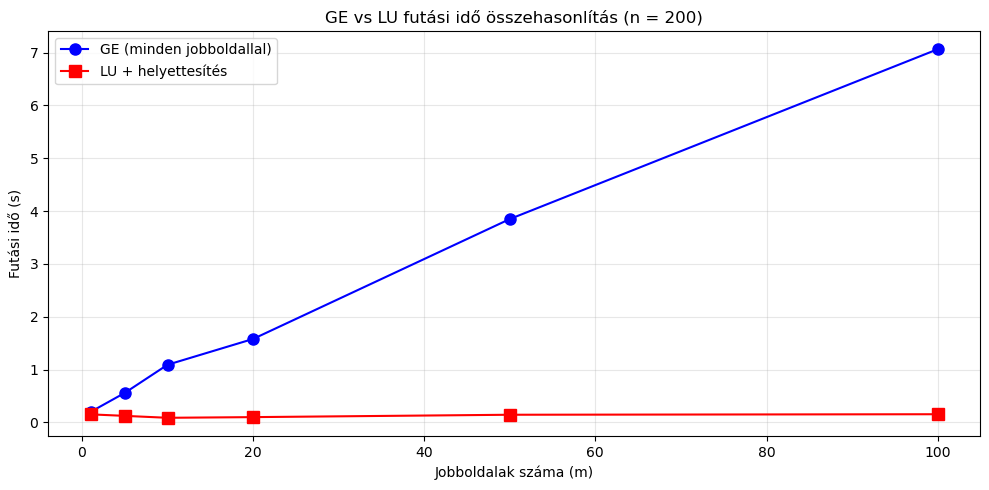

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(m_values, times_ge, 'bo-', markersize=8, label='GE (minden jobboldallal)')
ax.plot(m_values, times_lu, 'rs-', markersize=8, label='LU + helyettesítés')
ax.set_xlabel('Jobboldalak száma (m)')
ax.set_ylabel('Futási idő (s)')
ax.set_title(f'GE vs LU futási idő összehasonlítás (n = {n})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Vektornormák

### Definíció: vektornorma

Legyen $n \in \mathbb{N}$ rögzített. Az $\lVert.\rVert : \mathbb{R}^n \to \mathbb{R}$ leképezést **vektornormának** nevezzük, ha:

1. $\lVert x\rVert \ge 0$ $\quad (\forall x \in \mathbb{R}^n)$
2. $\lVert x\rVert = 0 \iff x = 0$
3. $\lVert\lambda \cdot x\rVert = |\lambda| \cdot \lVert x\rVert$ $\quad (\forall \lambda \in \mathbb{R}, \forall x \in \mathbb{R}^n)$
4. $\lVert x + y\rVert \le \lVert x\rVert + \lVert y\rVert$ $\quad (\forall x, y \in \mathbb{R}^n)$ — háromszög-egyenlőtlenség

### Gyakori vektornormák

- $\lVert x \rVert_1 = \sum_{i=1}^n |x_i|$ — **Manhattan-norma**
- $\lVert x \rVert_2 = \left(\sum_{i=1}^n |x_i|^2\right)^{1/2}$ — **Euklideszi-norma**
- $\lVert x \rVert_\infty = \max_{i=1}^n |x_i|$ — **Csebisev-norma**
- $\lVert x \rVert_p = \left(\sum_{i=1}^n |x_i|^p\right)^{1/p}$ — **$p$-norma** ($p \ge 1$)

In [19]:
# Példa az előadásból
x = np.array([3, 4], dtype=float)
y = np.array([4, -8, 1], dtype=float)

print("x =", x)
print(f"  ||x||_1   = {np.linalg.norm(x, 1):.4f}    (= 3 + 4 = 7)")
print(f"  ||x||_2   = {np.linalg.norm(x, 2):.4f}    (= sqrt(9+16) = 5)")
print(f"  ||x||_inf = {np.linalg.norm(x, np.inf):.4f}    (= max(3,4) = 4)")

print(f"\ny = {y}")
print(f"  ||y||_1   = {np.linalg.norm(y, 1):.4f}    (= 4+8+1 = 13)")
print(f"  ||y||_2   = {np.linalg.norm(y, 2):.4f}  (= sqrt(16+64+1) = sqrt(81))")
print(f"  ||y||_inf = {np.linalg.norm(y, np.inf):.4f}    (= max(4,8,1) = 8)")

x = [3. 4.]
  ||x||_1   = 7.0000    (= 3 + 4 = 7)
  ||x||_2   = 5.0000    (= sqrt(9+16) = 5)
  ||x||_inf = 4.0000    (= max(3,4) = 4)

y = [ 4. -8.  1.]
  ||y||_1   = 13.0000    (= 4+8+1 = 13)
  ||y||_2   = 9.0000  (= sqrt(16+64+1) = sqrt(81))
  ||y||_inf = 8.0000    (= max(4,8,1) = 8)


### Normák közötti egyenlőtlenségek

$$
\lVert x\rVert_\infty \le \lVert x\rVert_2 \le \lVert x\rVert_1 \le \sqrt{n} \cdot \lVert x\rVert_2 \le n \cdot \lVert x\rVert_\infty
$$

Minden végesdimenziós vektornorma **ekvivalens**: léteznek $c_1, c_2 > 0$ konstansok, hogy $c_1 \lVert x\rVert_a \le \lVert x\rVert_b \le c_2 \lVert x\rVert_a$.

In [20]:
# Egyenlőtlenségek ellenőrzése
x = np.array([3, 4], dtype=float)
n = len(x)

n1 = np.linalg.norm(x, 1)
n2 = np.linalg.norm(x, 2)
ninf = np.linalg.norm(x, np.inf)

print(f"x = {x}, n = {n}")
print(f"||x||_inf = {ninf:.2f}  ≤  ||x||_2 = {n2:.2f}  ≤  ||x||_1 = {n1:.2f}")
print(f"||x||_1 = {n1:.2f}  ≤  sqrt(n)·||x||_2 = {np.sqrt(n)*n2:.2f}")
print(f"||x||_2 = {n2:.2f}  ≤  sqrt(n)·||x||_inf = {np.sqrt(n)*ninf:.2f}")

x = [3. 4.], n = 2
||x||_inf = 4.00  ≤  ||x||_2 = 5.00  ≤  ||x||_1 = 7.00
||x||_1 = 7.00  ≤  sqrt(n)·||x||_2 = 7.07
||x||_2 = 5.00  ≤  sqrt(n)·||x||_inf = 5.66


## 9. Egységgömbök vizualizációja

A $p$-norma **egységgömbje** $\mathbb{R}^2$-ben:

$$
\{x \in \mathbb{R}^2 : \lVert x\rVert_p = 1\}
$$

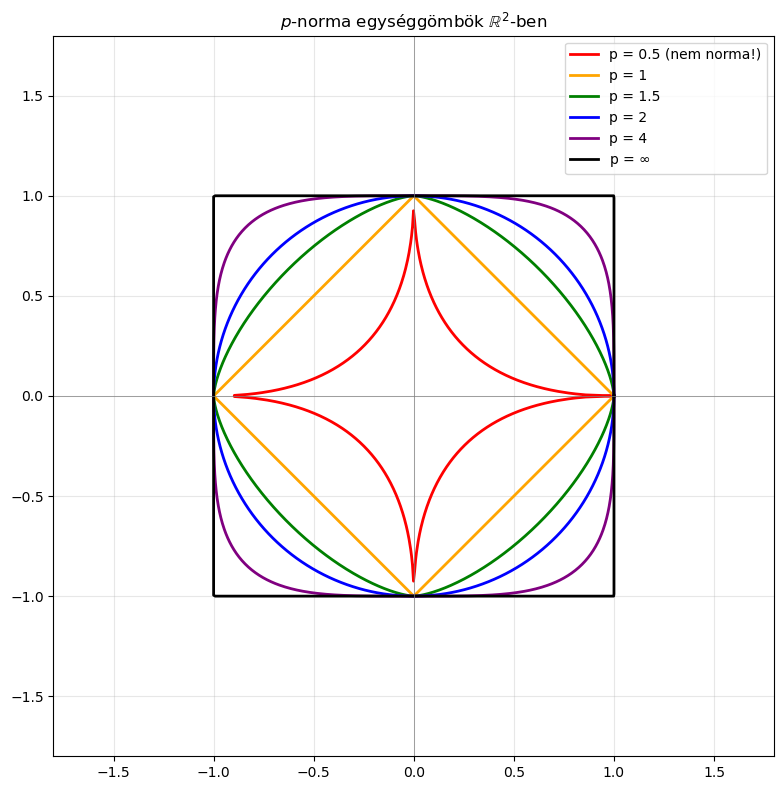

In [21]:
theta = np.linspace(0, 2 * np.pi, 1000)

def unit_ball_2d(p, n_points=1000):
    """p-norma egységgömb pontjai R^2-ben."""
    if p == np.inf:
        # Négyzet: [-1,1] x [-1,1]
        t = np.linspace(0, 2 * np.pi, n_points)
        x = np.cos(t)
        y = np.sin(t)
        # Normálás inf-normával
        norms = np.maximum(np.abs(x), np.abs(y))
        return x / norms, y / norms
    else:
        t = np.linspace(0, 2 * np.pi, n_points)
        x = np.cos(t)
        y = np.sin(t)
        norms = (np.abs(x)**p + np.abs(y)**p)**(1/p)
        return x / norms, y / norms

fig, ax = plt.subplots(figsize=(8, 8))

p_values = [0.5, 1, 1.5, 2, 4, np.inf]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'black']

for p, c in zip(p_values, colors):
    x, y = unit_ball_2d(p)
    label = f'p = {p}' if p != np.inf else r'p = $\infty$'
    if p < 1:
        label += ' (nem norma!)'
    ax.plot(x, y, color=c, linewidth=2, label=label)

ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.set_title(r'$p$-norma egységgömbök $\mathbb{R}^2$-ben')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 10. Mátrixnormák

### Definíció: mátrixnorma

Az $\lVert.\rVert : \mathbb{R}^{n \times n} \to \mathbb{R}$ leképezést **mátrixnormának** nevezzük, ha teljesíti a vektornorma axiómáit (1–4), plusz:

5. **Szubmultiplikativitás:** $\lVert A \cdot B\rVert \le \lVert A\rVert \cdot \lVert B\rVert$ $\quad (\forall A, B \in \mathbb{R}^{n \times n})$

### Frobenius-norma

$$
\lVert A\rVert_F = \left( \sum_{i=1}^n \sum_{j=1}^n |a_{ij}|^2 \right)^{1/2}
$$

### Indukált (természetes) mátrixnormák

Legyen $\lVert.\rVert_v$ vektornorma. Az általa **indukált mátrixnorma:**

$$
\lVert A\rVert := \sup_{x \neq 0} \frac{\lVert Ax\rVert_v}{\lVert x\rVert_v} = \sup_{\lVert y\rVert_v = 1} \lVert Ay\rVert_v
$$

### Nevezetes indukált mátrixnormák

- $\lVert A\rVert_1 = \max_j \sum_i |a_{ij}|$ — **Oszlopnorma**
- $\lVert A\rVert_\infty = \max_i \sum_j |a_{ij}|$ — **Sornorma**
- $\lVert A\rVert_2 = \sqrt{\max_i \lambda_i(A^\top A)}$ — **Spektrálnorma**

In [22]:
# Példák az előadásból
A = np.array([[1, -4],
              [2,  2]], dtype=float)
B = np.array([[3, 2],
              [1, 5]], dtype=float)

# Frobenius-norma
print("=== Frobenius-norma ===")
print(f"||A||_F = sqrt(1+16+4+4) = {np.linalg.norm(A, 'fro'):.4f}  (= 5)")
print(f"||B||_F = sqrt(9+4+1+25) = {np.linalg.norm(B, 'fro'):.4f}  (≈ 6.245)")

=== Frobenius-norma ===
||A||_F = sqrt(1+16+4+4) = 5.0000  (= 5)
||B||_F = sqrt(9+4+1+25) = 6.2450  (≈ 6.245)


In [23]:
# Indukált mátrixnormák
A = np.array([[1, -4],
              [2,  2]], dtype=float)

print("A =")
print(A)

# 1-norma (oszlopnorma): max oszlopösszeg
norm1 = np.linalg.norm(A, 1)
print(f"\n||A||_1 = max(1+2, |-4|+2) = max(3, 6) = {norm1:.0f}")

# inf-norma (sornorma): max sorösszeg
norminf = np.linalg.norm(A, np.inf)
print(f"||A||_inf = max(1+|-4|, 2+2) = max(5, 4) = {norminf:.0f}")

# 2-norma (spektrálnorma)
ATA = A.T @ A
eigenvalues = np.linalg.eigvalsh(ATA)
norm2 = np.sqrt(np.max(eigenvalues))
print(f"\nA^T · A = {ATA}")
print(f"λ(A^T A) = {eigenvalues}")
print(f"||A||_2 = sqrt(max λ) = sqrt({np.max(eigenvalues):.0f}) = {norm2:.4f}")
print(f"np.linalg.norm(A, 2) = {np.linalg.norm(A, 2):.4f}")

A =
[[ 1. -4.]
 [ 2.  2.]]

||A||_1 = max(1+2, |-4|+2) = max(3, 6) = 6
||A||_inf = max(1+|-4|, 2+2) = max(5, 4) = 5

A^T · A = [[ 5.  0.]
 [ 0. 20.]]
λ(A^T A) = [ 5. 20.]
||A||_2 = sqrt(max λ) = sqrt(20) = 4.4721
np.linalg.norm(A, 2) = 4.4721


## 11. Indukált mátrixnorma szemléltetése

Az indukált mátrixnorma geometriai jelentése: az $A$ mátrix milyen mértékben "nyújtja" a vektorokat.

$$
\lVert A\rVert_2 = \max_{\lVert x\rVert_2 = 1} \lVert Ax\rVert_2
$$

Vagyis az egységkör képe $A$ transzformáció alatt egy ellipszis, és $\lVert A\rVert_2$ az ellipszis félnagytengely-hossza.

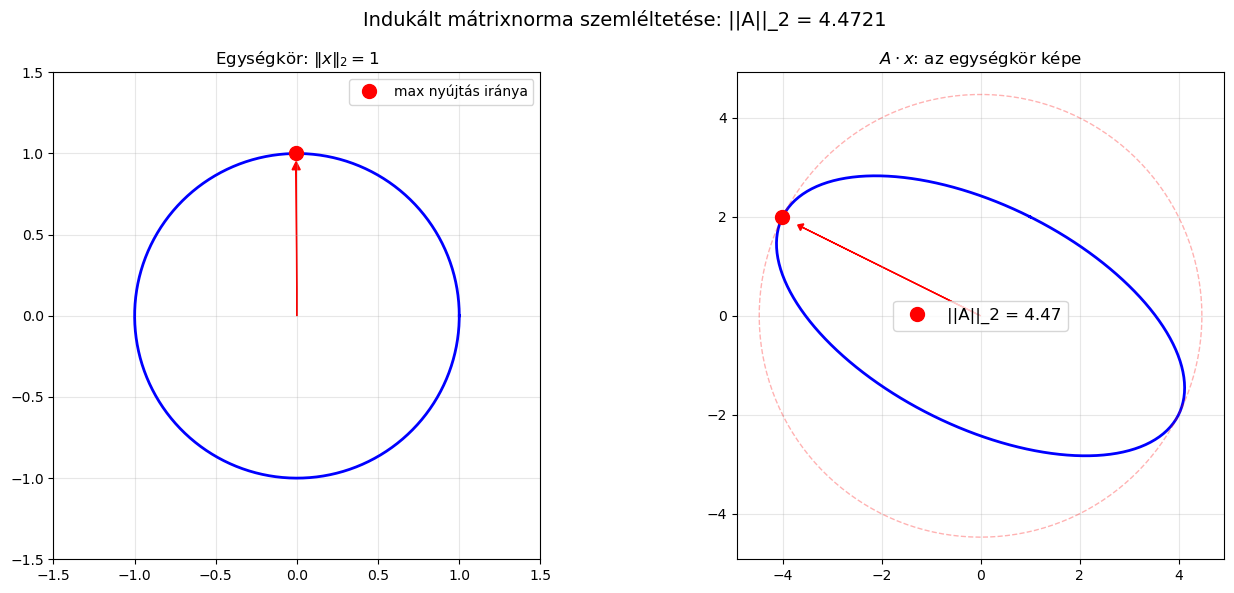

In [24]:
A = np.array([[1, -4],
              [2,  2]], dtype=float)

# Egységkör pontjai
theta = np.linspace(0, 2 * np.pi, 300)
circle = np.array([np.cos(theta), np.sin(theta)])  # 2 x N

# Transzformált pontok
ellipse = A @ circle  # 2 x N

# Normák kiszámítása
norms = np.linalg.norm(ellipse, axis=0)
max_idx = np.argmax(norms)
min_idx = np.argmin(norms)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bal: egységkör
axes[0].plot(circle[0], circle[1], 'b-', linewidth=2)
axes[0].plot(circle[0, max_idx], circle[1, max_idx], 'ro', markersize=10, label='max nyújtás iránya')
axes[0].arrow(0, 0, circle[0, max_idx]*0.9, circle[1, max_idx]*0.9,
              head_width=0.05, head_length=0.05, fc='red', ec='red')
axes[0].set_xlim(-1.5, 1.5)
axes[0].set_ylim(-1.5, 1.5)
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)
axes[0].set_title(r'Egységkör: $\|x\|_2 = 1$')
axes[0].legend()

# Jobb: transzformált (ellipszis)
axes[1].plot(ellipse[0], ellipse[1], 'b-', linewidth=2)
axes[1].plot(ellipse[0, max_idx], ellipse[1, max_idx], 'ro', markersize=10, 
             label=f'||A||_2 = {norms[max_idx]:.2f}')
axes[1].arrow(0, 0, ellipse[0, max_idx]*0.9, ellipse[1, max_idx]*0.9,
              head_width=0.15, head_length=0.1, fc='red', ec='red')
# Sugárkör a max normával
max_circle = norms[max_idx] * np.array([np.cos(theta), np.sin(theta)])
axes[1].plot(max_circle[0], max_circle[1], 'r--', alpha=0.3, linewidth=1)
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)
axes[1].set_title(r'$A \cdot x$: az egységkör képe')
axes[1].legend(fontsize=12)

plt.suptitle(f'Indukált mátrixnorma szemléltetése: ||A||_2 = {np.linalg.norm(A, 2):.4f}', fontsize=14)
plt.tight_layout()
plt.show()

### Indukált mátrixnorma közelítő számítása

Az indukált normát közelíthetjük véletlenszerű vektorok próbálgatásával:

$$
\lVert A\rVert \approx \max_{i=1}^m \frac{\lVert Ax_i\rVert_p}{\lVert x_i\rVert_p}
$$

In [25]:
def approx_induced_norm(A, p=2, m=1000):
    """Indukált mátrixnorma közelítése m darab véletlenszerű vektorral."""
    n = A.shape[1]
    max_ratio = 0
    for _ in range(m):
        x = np.random.randn(n)
        Ax = A @ x
        ratio = np.linalg.norm(Ax, p) / np.linalg.norm(x, p)
        max_ratio = max(max_ratio, ratio)
    return max_ratio

A = np.array([[1, -4],
              [2,  2]], dtype=float)

print(f"{'p':>5} {'Közelítő':>12} {'Pontos':>12}")
print("-" * 32)
for p in [1, 2, np.inf]:
    approx = approx_induced_norm(A, p, m=5000)
    exact = np.linalg.norm(A, p)
    p_str = 'inf' if p == np.inf else str(int(p))
    print(f"{p_str:>5} {approx:>12.4f} {exact:>12.4f}")

    p     Közelítő       Pontos
--------------------------------
    1       5.9990       6.0000
    2       4.4721       4.4721
  inf       4.9998       5.0000


## 12. Spektrálsugár

### Definíció

Egy $A \in \mathbb{R}^{n \times n}$ mátrix **spektrálsugara:**

$$
\varrho(A) := \max_{i=1}^n |\lambda_i(A)|
$$

ahol $\lambda_i(A)$ az $A$ sajátértékei.

### Tulajdonságok

- $\lVert A\rVert_2 = \sqrt{\varrho(A^\top A)}$
- Ha $A$ szimmetrikus: $\lVert A\rVert_2 = \varrho(A)$
- $\varrho(A) \le \lVert A\rVert$ tetszőleges mátrixnormára
- Ha $Q$ ortogonális: $\lVert Qx\rVert_2 = \lVert x\rVert_2$, $\lVert Q\rVert_2 = 1$, $\lVert QA\rVert_2 = \lVert AQ\rVert_2 = \lVert A\rVert_2$

In [26]:
# Spektrálsugár és mátrixnormák
A = np.array([[1, -4],
              [2,  2]], dtype=float)

eigenvalues_A = np.linalg.eigvals(A)
rho_A = np.max(np.abs(eigenvalues_A))

print(f"A sajátértékei: {eigenvalues_A}")
print(f"ρ(A) = {rho_A:.4f}")
print(f"||A||_1 = {np.linalg.norm(A, 1):.4f}")
print(f"||A||_2 = {np.linalg.norm(A, 2):.4f}")
print(f"||A||_inf = {np.linalg.norm(A, np.inf):.4f}")
print(f"||A||_F = {np.linalg.norm(A, 'fro'):.4f}")
print(f"\nρ(A) ≤ ||A|| teljesül minden normára? ", end="")
print(rho_A <= np.linalg.norm(A, 1) and 
      rho_A <= np.linalg.norm(A, 2) and 
      rho_A <= np.linalg.norm(A, np.inf))

A sajátértékei: [1.5+2.7839j 1.5-2.7839j]
ρ(A) = 3.1623
||A||_1 = 6.0000
||A||_2 = 4.4721
||A||_inf = 5.0000
||A||_F = 5.0000

ρ(A) ≤ ||A|| teljesül minden normára? True


In [27]:
# Szimmetrikus mátrix: ||A||_2 = ρ(A)
S = np.array([[4, 2],
              [2, 1]], dtype=float)

eigenvalues_S = np.linalg.eigvalsh(S)
rho_S = np.max(np.abs(eigenvalues_S))
norm2_S = np.linalg.norm(S, 2)

print(f"S (szimmetrikus) =\n{S}")
print(f"\nSajátértékek: {eigenvalues_S}")
print(f"ρ(S)    = {rho_S:.4f}")
print(f"||S||_2 = {norm2_S:.4f}")
print(f"\nρ(S) = ||S||_2? {np.isclose(rho_S, norm2_S)}")

S (szimmetrikus) =
[[4. 2.]
 [2. 1.]]

Sajátértékek: [0. 5.]
ρ(S)    = 5.0000
||S||_2 = 5.0000

ρ(S) = ||S||_2? True


In [28]:
# A Frobenius-norma NEM természetes (indukált) mátrixnorma
# Bizonyítás: ||I||_F = sqrt(n) ≠ 1

for n in [2, 3, 5, 10]:
    I_n = np.eye(n)
    print(f"n = {n:>2}: ||I||_F = {np.linalg.norm(I_n, 'fro'):.4f},  "
          f"||I||_2 = {np.linalg.norm(I_n, 2):.4f}")

print("\n→ Indukált normák esetén ||I|| = 1, de ||I||_F = sqrt(n).")
print("  Tehát a Frobenius-norma nem természetes mátrixnorma.")

n =  2: ||I||_F = 1.4142,  ||I||_2 = 1.0000
n =  3: ||I||_F = 1.7321,  ||I||_2 = 1.0000
n =  5: ||I||_F = 2.2361,  ||I||_2 = 1.0000
n = 10: ||I||_F = 3.1623,  ||I||_2 = 1.0000

→ Indukált normák esetén ||I|| = 1, de ||I||_F = sqrt(n).
  Tehát a Frobenius-norma nem természetes mátrixnorma.


### Összefoglalás

| Téma | Lényeg |
|------|--------|
| **LU-felbontás** | $A = LU$, $L \in \mathcal{L}_1$, $U \in \mathcal{U}$ |
| **LU GE-vel** | $L$ elemei a GE-s hányadosok, $U$ a felső háromszög alak |
| **LU közvetlen** | Mátrixszorzás alapján, sorfolytonos/parkettás bejárással |
| **LER megoldás LU-val** | $Ly = b$ (előre), $Ux = y$ (vissza), összesen $2n^2$ |
| **Műveletigény** | LU-felbontás: $\frac{2}{3}n^3$, több jobboldal esetén nagy előny |
| **Vektornorma** | $1, 2, \infty, p$-normák; véges dimenzióban mind ekvivalens |
| **Mátrixnorma** | Frobenius, indukált normák ($1, 2, \infty$) |
| **Spektrálsugár** | $\varrho(A) \le \lVert A\rVert$; szimmetrikusra $\lVert A\rVert_2 = \varrho(A)$ |

---
# III. rész – Feladatok

### 1. feladat: LU-felbontás

Készítsd el a következő mátrix LU-felbontását!

$$
A = \begin{bmatrix} 1 & 2 & 3 \\ 2 & 8 & 4 \\ 3 & 4 & 11 \end{bmatrix}
$$

Ellenőrizd, hogy $L \cdot U = A$.

In [29]:
# Megoldás
A1 = np.array([[1, 2, 3],
               [2, 8, 4],
               [3, 4, 11]], dtype=float)

L1, U1 = lu_decomposition_ge(A1, verbose=True)
print(f"L =\n{L1}")
print(f"\nU =\n{U1}")
print(f"\nL @ U = A? {np.allclose(L1 @ U1, A1)}")

--- 1. lépés után ---
U =
[[ 1.  2.  3.]
 [ 0.  4. -2.]
 [ 0. -2.  2.]]
L (eddig) =
[[1. 0. 0.]
 [2. 1. 0.]
 [3. 0. 1.]]

--- 2. lépés után ---
U =
[[ 1.  2.  3.]
 [ 0.  4. -2.]
 [ 0.  0.  1.]]
L (eddig) =
[[ 1.   0.   0. ]
 [ 2.   1.   0. ]
 [ 3.  -0.5  1. ]]

L =
[[ 1.   0.   0. ]
 [ 2.   1.   0. ]
 [ 3.  -0.5  1. ]]

U =
[[ 1.  2.  3.]
 [ 0.  4. -2.]
 [ 0.  0.  1.]]

L @ U = A? True


### 2. feladat: LER megoldása LU-felbontással

Oldd meg az alábbi lineáris egyenletrendszert LU-felbontással!

$$
\begin{bmatrix} 4 & -1 & 0 \\ -1 & 4 & -1 \\ 0 & -1 & 4 \end{bmatrix}
\cdot x =
\begin{bmatrix} 5 \\ -7 \\ 13 \end{bmatrix}
$$

Majd oldd meg egy második jobboldallal is: $b_2 = [1, 0, 1]^\top$.

In [30]:
# Megoldás
A2 = np.array([[4, -1, 0],
               [-1, 4, -1],
               [0, -1, 4]], dtype=float)
b2_1 = np.array([5, -7, 13], dtype=float)
b2_2 = np.array([1, 0, 1], dtype=float)

# LU-felbontás egyszer
L2, U2 = lu_decomposition_ge(A2)
print(f"L =\n{L2}")
print(f"\nU =\n{U2}")

# 1. jobboldal
x2_1 = solve_lu(L2, U2, b2_1)
print(f"\n1. jobboldal: x = {x2_1}")
print(f"Ellenőrzés: {np.allclose(A2 @ x2_1, b2_1)}")

# 2. jobboldal (LU-t nem kell újraszámolni!)
x2_2 = solve_lu(L2, U2, b2_2)
print(f"\n2. jobboldal: x = {x2_2}")
print(f"Ellenőrzés: {np.allclose(A2 @ x2_2, b2_2)}")

L =
[[ 1.      0.      0.    ]
 [-0.25    1.      0.    ]
 [ 0.     -0.2667  1.    ]]

U =
[[ 4.     -1.      0.    ]
 [ 0.      3.75   -1.    ]
 [ 0.      0.      3.7333]]

1. jobboldal: x = [ 1.0714 -0.7143  3.0714]
Ellenőrzés: True

2. jobboldal: x = [0.2857 0.1429 0.2857]
Ellenőrzés: True


### 3. feladat: LU-felbontás nem létezik

Mutasd meg, hogy az alábbi mátrixnak nem létezik LU-felbontása (sorcsere nélkül), és magyarázd meg miért!

$$
C = \begin{bmatrix} 0 & 1 & 2 \\ 1 & 3 & 1 \\ 2 & 1 & 5 \end{bmatrix}
$$

In [31]:
# Megoldás
C = np.array([[0, 1, 2],
              [1, 3, 1],
              [2, 1, 5]], dtype=float)

print("C mátrix:")
print(C)
print(f"\ndet(C) = {np.linalg.det(C):.2f} (≠ 0, tehát invertálható)")

try:
    L_c, U_c = lu_decomposition_ge(C)
    print("LU-felbontás sikerült.")
except ValueError as e:
    print(f"\nHiba: {e}")
    print("\nMagyarázat: a_{11} = 0, tehát az első pivot nulla.")
    print("Az LU-felbontás nem létezik sorcsere nélkül, mert D_1 = a_{11} = 0.")
    print("De a mátrix invertálható, tehát PLU-felbontás létezik!")

# scipy PLU-felbontással megoldható
from scipy.linalg import lu as scipy_lu
P, L_c, U_c = scipy_lu(C)
print(f"\nscipy PLU-felbontás:")
print(f"P =\n{P}")
print(f"L =\n{L_c}")
print(f"U =\n{U_c}")
print(f"P @ L @ U = C? {np.allclose(P @ L_c @ U_c, C)}")

C mátrix:
[[0. 1. 2.]
 [1. 3. 1.]
 [2. 1. 5.]]

det(C) = -13.00 (≠ 0, tehát invertálható)

Hiba: Nulla pivot a 1. lépésben! LU-felbontás nem létezik (sorcsere nélkül).

Magyarázat: a_{11} = 0, tehát az első pivot nulla.
Az LU-felbontás nem létezik sorcsere nélkül, mert D_1 = a_{11} = 0.
De a mátrix invertálható, tehát PLU-felbontás létezik!

scipy PLU-felbontás:
P =
[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]
L =
[[1.  0.  0. ]
 [0.5 1.  0. ]
 [0.  0.4 1. ]]
U =
[[ 2.   1.   5. ]
 [ 0.   2.5 -1.5]
 [ 0.   0.   2.6]]
P @ L @ U = C? True


### 4. feladat: Vektornormák

Számítsd ki a következő vektorok $1, 2, \infty$ normáját kézzel, majd ellenőrizd Python-nal!

$$
u = \begin{bmatrix} -2 \\ 3 \\ 6 \end{bmatrix}, \qquad
v = \begin{bmatrix} 1 \\ -1 \\ 1 \\ -1 \end{bmatrix}
$$

Ellenőrizd a normák közötti egyenlőtlenségeket is!

In [32]:
# Megoldás
u = np.array([-2, 3, 6], dtype=float)
v = np.array([1, -1, 1, -1], dtype=float)

for vec, name in [(u, 'u'), (v, 'v')]:
    n = len(vec)
    n1 = np.linalg.norm(vec, 1)
    n2 = np.linalg.norm(vec, 2)
    ninf = np.linalg.norm(vec, np.inf)
    
    print(f"{name} = {vec}")
    print(f"  ||{name}||_1   = {n1:.4f}")
    print(f"  ||{name}||_2   = {n2:.4f}")
    print(f"  ||{name}||_inf = {ninf:.4f}")
    
    # Egyenlőtlenségek
    print(f"  Egyenlőtlenségek:")
    print(f"    ||{name}||_inf ≤ ||{name}||_2 ≤ ||{name}||_1: "
          f"{ninf:.2f} ≤ {n2:.2f} ≤ {n1:.2f} → {ninf <= n2 + 1e-10 and n2 <= n1 + 1e-10}")
    print(f"    ||{name}||_1 ≤ sqrt(n)·||{name}||_2: "
          f"{n1:.2f} ≤ {np.sqrt(n)*n2:.2f} → {n1 <= np.sqrt(n)*n2 + 1e-10}")
    print()

u = [-2.  3.  6.]
  ||u||_1   = 11.0000
  ||u||_2   = 7.0000
  ||u||_inf = 6.0000
  Egyenlőtlenségek:
    ||u||_inf ≤ ||u||_2 ≤ ||u||_1: 6.00 ≤ 7.00 ≤ 11.00 → True
    ||u||_1 ≤ sqrt(n)·||u||_2: 11.00 ≤ 12.12 → True

v = [ 1. -1.  1. -1.]
  ||v||_1   = 4.0000
  ||v||_2   = 2.0000
  ||v||_inf = 1.0000
  Egyenlőtlenségek:
    ||v||_inf ≤ ||v||_2 ≤ ||v||_1: 1.00 ≤ 2.00 ≤ 4.00 → True
    ||v||_1 ≤ sqrt(n)·||v||_2: 4.00 ≤ 4.00 → True



### 5. feladat: Mátrixnormák

Számítsd ki a következő mátrix Frobenius-, $1$-, $\infty$-, és $2$-normáját!

$$
M = \begin{bmatrix} 3 & -1 & 0 \\ 2 & 4 & -2 \\ 0 & -1 & 5 \end{bmatrix}
$$

Számítsd ki a spektrálsugarat is, és ellenőrizd, hogy $\varrho(M) \le \|M\|$ minden normára!

In [33]:
# Megoldás
M = np.array([[3, -1, 0],
              [2, 4, -2],
              [0, -1, 5]], dtype=float)

print("M =")
print(M)

nF = np.linalg.norm(M, 'fro')
n1 = np.linalg.norm(M, 1)
ninf = np.linalg.norm(M, np.inf)
n2 = np.linalg.norm(M, 2)

print(f"\n||M||_F   = {nF:.4f}")
print(f"||M||_1   = {n1:.4f}  (max oszlopösszeg)")
print(f"||M||_inf = {ninf:.4f}  (max sorösszeg)")
print(f"||M||_2   = {n2:.4f}  (spektrálnorma)")

# Spektrálsugár
eigenvalues_M = np.linalg.eigvals(M)
rho_M = np.max(np.abs(eigenvalues_M))
print(f"\nSajátértékek: {eigenvalues_M}")
print(f"ρ(M) = {rho_M:.4f}")

print(f"\nρ(M) ≤ ||M||_F?   {rho_M:.4f} ≤ {nF:.4f} → {rho_M <= nF + 1e-10}")
print(f"ρ(M) ≤ ||M||_1?   {rho_M:.4f} ≤ {n1:.4f} → {rho_M <= n1 + 1e-10}")
print(f"ρ(M) ≤ ||M||_inf? {rho_M:.4f} ≤ {ninf:.4f} → {rho_M <= ninf + 1e-10}")
print(f"ρ(M) ≤ ||M||_2?   {rho_M:.4f} ≤ {n2:.4f} → {rho_M <= n2 + 1e-10}")

M =
[[ 3. -1.  0.]
 [ 2.  4. -2.]
 [ 0. -1.  5.]]

||M||_F   = 7.7460
||M||_1   = 7.0000  (max oszlopösszeg)
||M||_inf = 8.0000  (max sorösszeg)
||M||_2   = 6.2490  (spektrálnorma)

Sajátértékek: [3.1018+1.1917j 3.1018-1.1917j 5.7963+0.j    ]
ρ(M) = 5.7963

ρ(M) ≤ ||M||_F?   5.7963 ≤ 7.7460 → True
ρ(M) ≤ ||M||_1?   5.7963 ≤ 7.0000 → True
ρ(M) ≤ ||M||_inf? 5.7963 ≤ 8.0000 → True
ρ(M) ≤ ||M||_2?   5.7963 ≤ 6.2490 → True


### 6. feladat: Egységgömbök

Rajzold meg a $p$-norma egységgömbjét $\mathbb{R}^2$-ben az alábbi $p$ értékekre: $p = 0.5, 1, 1.5, 2, 4, \infty$.

Melyik értékekre lesz konvex az egységgömb? Miért nem norma a $p < 1$ eset?

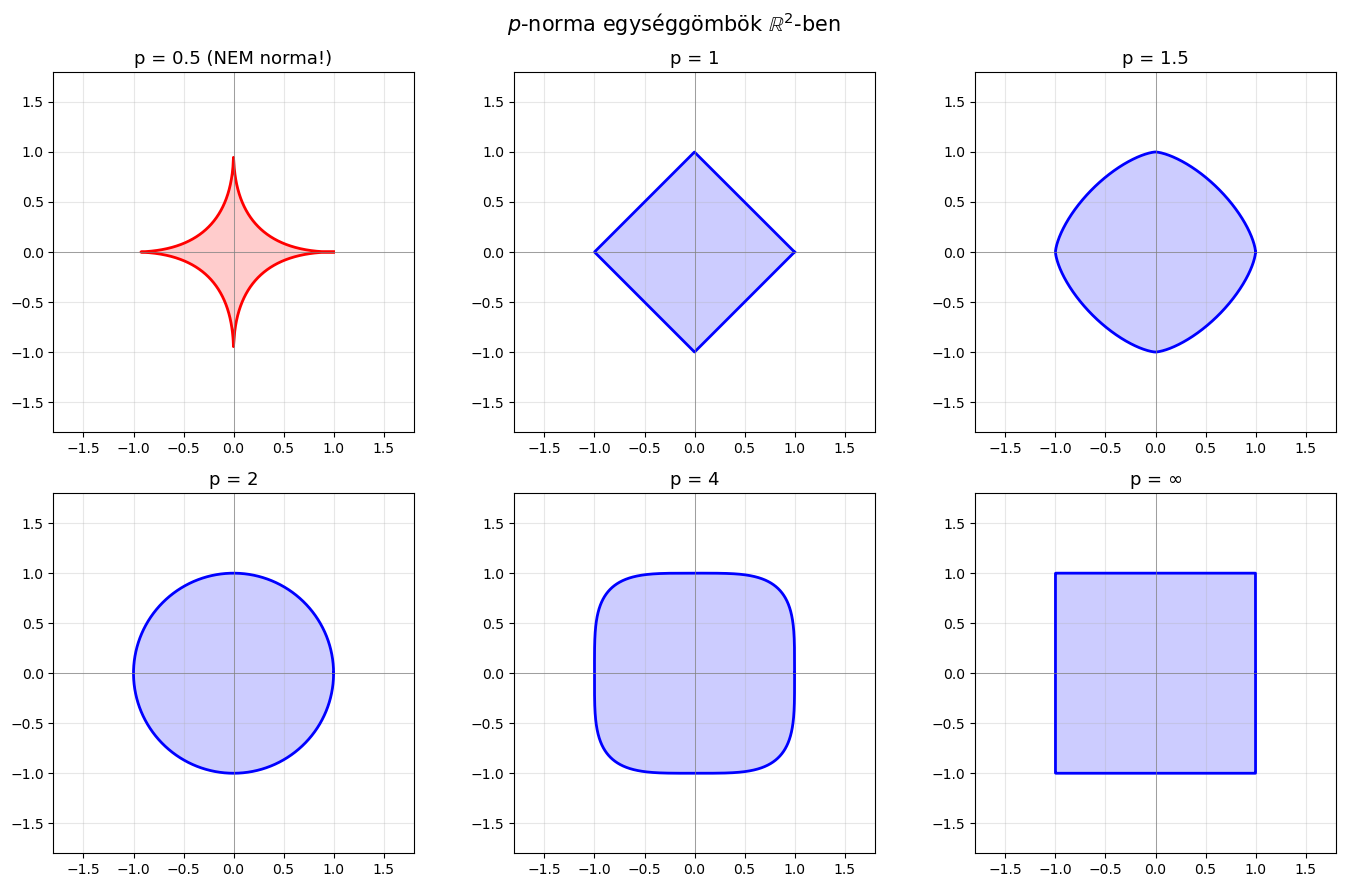

p ≥ 1 esetén az egységgömb konvex → valódi norma.
p < 1 esetén az egységgömb nem konvex → nem teljesül a háromszög-egyenlőtlenség.


In [34]:
# Megoldás
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
p_values = [0.5, 1, 1.5, 2, 4, np.inf]

for ax, p in zip(axes.flat, p_values):
    x, y = unit_ball_2d(p, n_points=2000)
    
    is_norm = p >= 1
    color = 'blue' if is_norm else 'red'
    label = f'p = {p}' if p != np.inf else r'p = $\infty$'
    
    ax.fill(x, y, alpha=0.2, color=color)
    ax.plot(x, y, color=color, linewidth=2)
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.8, 1.8)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    
    title = label
    if not is_norm:
        title += ' (NEM norma!)'
    ax.set_title(title, fontsize=13)

plt.suptitle(r'$p$-norma egységgömbök $\mathbb{R}^2$-ben', fontsize=15)
plt.tight_layout()
plt.show()

print("p ≥ 1 esetén az egységgömb konvex → valódi norma.")
print("p < 1 esetén az egységgömb nem konvex → nem teljesül a háromszög-egyenlőtlenség.")